In [7]:
import numpy as np
import pandas as pd

np.random.seed(23)
mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)
df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)
df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])
df1['target'] = 0

df = pd.concat([df, df1], ignore_index=True)

df = df.sample(40)



#Above is just an example created of 40 rows and 4 columns dataset; 
DataFrame.append() has been removed in pandas 2.0, so dont use:  
df = df.append(df1,ignore_index=True),use: 
df = pd.concat([df, df1], ignore_index=True)

#A seed creates random data, Every time you run the code with seed 23, you get the same random values, mu_vec1 is mean vector of class 1, covariance matrix, generate 20 random samples, convert them to dataframe, add a target column. similarly, create a class2, then concat/append(combine) the datasets, ignore_index=True means to create a new index here 0 to 39, df.sample rshuffles values.

In [8]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


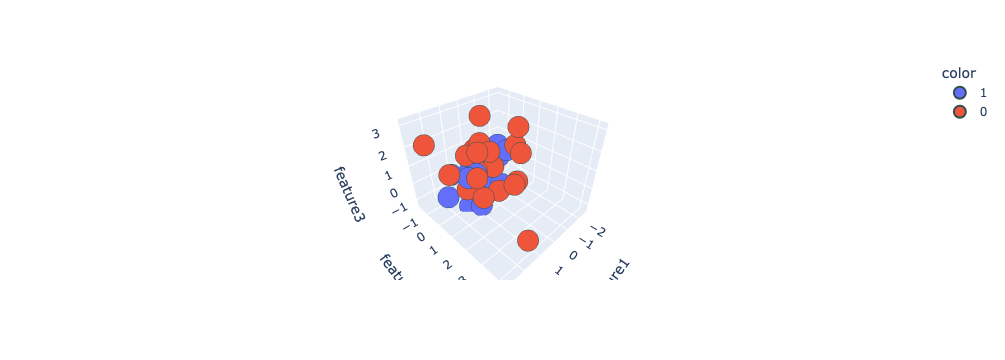

In [9]:
#Dispalying data in 3D
import plotly.express as px

fig = px.scatter_3d(df,x=df['feature1'],y=df['feature2'],z=df['feature3'],
                    color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12, line=dict(width=2,color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()

In [13]:
#Applying Standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [17]:
#Covariance matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n',covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [20]:
#Finding Eigen values and Eigen vectors
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)
print("Eigen Values:")
print(eigen_values)

print("\nEigen Vectors:")
print(eigen_vectors)

Eigen Values:
[1.3536065  0.94557084 0.77774573]

Eigen Vectors:
[[-0.53875915 -0.69363291  0.47813384]
 [-0.65608325 -0.01057596 -0.75461442]
 [-0.52848211  0.72025103  0.44938304]]


%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


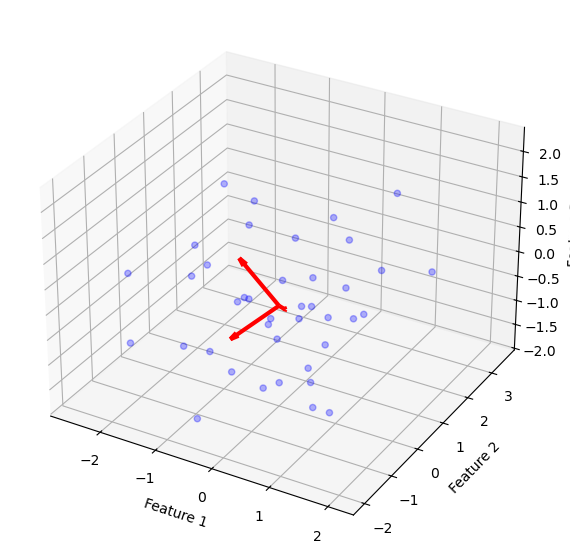

In [38]:
#Plotting eigen vectors in above 3D data
%pylab inline

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch

class Arrow3D(FancyArrowPatch):

    def __init__(self, xs, ys, zs, *args, **kwargs):
      FancyArrowPatch.__init__(self, (0,0), (0,0), *args, **kwargs)
      self._verts3d = xs, ys, zs
    
    def draw(self, renderer):
      xs3d, ys3d, zs3d = self._verts3d
      xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, renderer.M)
      self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
      FancyArrowPatch.draw(self, renderer)

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['feature1'], df['feature2'], df['feature3'],
           color='blue', alpha=0.3)

mean = df[['feature1','feature2','feature3']].mean().values

for v in eigen_vectors.T:
    ax.quiver(mean[0], mean[1], mean[2],
              v[0], v[1], v[2],
              color='red',
              linewidth=3,
              arrow_length_ratio=0.15)

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')

plt.show()